In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

loan_df = pd.read_csv("../Data/Loan_Default.csv")

loan_df.head()

,ID,year,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,...,credit_type,Credit_Score,co-applicant_credit_type,age,submission_of_application,LTV,Region,Security_Type,Status,dtir1
0,24890,2019,cf,Sex Not Available,nopre,type1,p1,l1,nopc,nob/c,...,EXP,758,CIB,25-34,to_inst,98.728814,south,direct,1,45.0
1,24891,2019,cf,Male,nopre,type2,p1,l1,nopc,b/c,...,EQUI,552,EXP,55-64,to_inst,NaN,North,direct,1,NaN
2,24892,2019,cf,Male,pre,type1,p1,l1,nopc,nob/c,...,EXP,834,CIB,35-44,to_inst,80.019685,south,direct,0,46.0
3,24893,2019,cf,Male,nopre,type1,p4,l1,nopc,nob/c,...,EXP,587,CIB,45-54,not_inst,69.376900,North,direct,0,42.0
4,24894,2019,cf,Joint,pre,type1,p1,l1,nopc,nob/c,...,CRIF,602,EXP,25-34,not_inst,91.886544,North,direct,0,39.0


In [2]:
loan_df["income"] = loan_df["income"].fillna(loan_df["income"].mean())
loan_df["loan_amount"] = loan_df["loan_amount"].fillna(loan_df["loan_amount"].mean())

loan_df

,ID,year,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,...,credit_type,Credit_Score,co-applicant_credit_type,age,submission_of_application,LTV,Region,Security_Type,Status,dtir1
0,24890,2019,cf,Sex Not Available,nopre,type1,p1,l1,nopc,nob/c,...,EXP,758,CIB,25-34,to_inst,98.728814,south,direct,1,45.0
1,24891,2019,cf,Male,nopre,type2,p1,l1,nopc,b/c,...,EQUI,552,EXP,55-64,to_inst,NaN,North,direct,1,NaN
2,24892,2019,cf,Male,pre,type1,p1,l1,nopc,nob/c,...,EXP,834,CIB,35-44,to_inst,80.019685,south,direct,0,46.0
3,24893,2019,cf,Male,nopre,type1,p4,l1,nopc,nob/c,...,EXP,587,CIB,45-54,not_inst,69.376900,North,direct,0,42.0
4,24894,2019,cf,Joint,pre,type1,p1,l1,nopc,nob/c,...,CRIF,602,EXP,25-34,not_inst,91.886544,North,direct,0,39.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
148665,173555,2019,cf,Sex Not Available,nopre,type1,p3,l1,nopc,nob/c,...,CIB,659,EXP,55-64,to_inst,71.792763,south,direct,0,48.0
148666,173556,2019,cf,Male,nopre,type1,p1,l1,nopc,nob/c,...,CIB,569,CIB,25-34,not_inst,74.428934,south,direct,0,15.0
148667,173557,2019,cf,Male,nopre,type1,p4,l1,nopc,nob/c,...,CIB,702,EXP,45-54,not_inst,61.332418,North,direct,0,49.0
148668,173558,2019,cf,Female,nopre,type1,p4,l1,nopc,nob/c,...,EXP,737,EXP,55-64,to_inst,70.683453,North,direct,0,29.0


In [3]:
loan_df = loan_df.assign(
    total_units = loan_df["total_units"].map({
        "1U": "1U",
        "2U": "2U+",
        "3U": "2U+",
        "4U": "2U+"}),
    loan_amt_v_income = loan_df["loan_amount"]/loan_df["income"]
)

loan_df.head()

,ID,year,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,...,Credit_Score,co-applicant_credit_type,age,submission_of_application,LTV,Region,Security_Type,Status,dtir1,loan_amt_v_income
0,24890,2019,cf,Sex Not Available,nopre,type1,p1,l1,nopc,nob/c,...,758,CIB,25-34,to_inst,98.728814,south,direct,1,45.0,66.954023
1,24891,2019,cf,Male,nopre,type2,p1,l1,nopc,b/c,...,552,EXP,55-64,to_inst,NaN,North,direct,1,NaN,41.465863
2,24892,2019,cf,Male,pre,type1,p1,l1,nopc,nob/c,...,834,CIB,35-44,to_inst,80.019685,south,direct,0,46.0,42.879747
3,24893,2019,cf,Male,nopre,type1,p4,l1,nopc,nob/c,...,587,CIB,45-54,not_inst,69.376900,North,direct,0,42.0,38.425926
4,24894,2019,cf,Joint,pre,type1,p1,l1,nopc,nob/c,...,602,EXP,25-34,not_inst,91.886544,North,direct,0,39.0,66.714559


<Axes: >

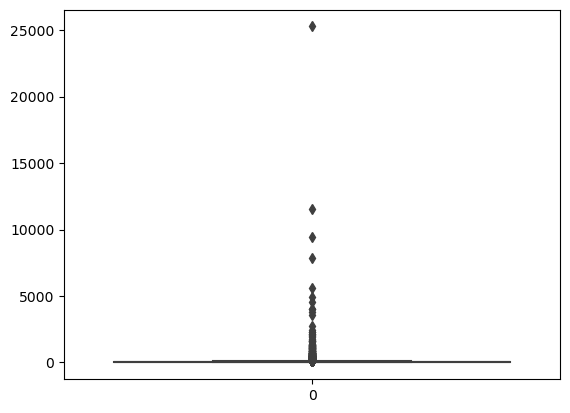

In [4]:
sns.boxplot(loan_df["loan_amt_v_income"])

In [5]:
loan_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148670 entries, 0 to 148669
Data columns (total 35 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   ID                         148670 non-null  int64  
 1   year                       148670 non-null  int64  
 2   loan_limit                 145326 non-null  object 
 3   Gender                     148670 non-null  object 
 4   approv_in_adv              147762 non-null  object 
 5   loan_type                  148670 non-null  object 
 6   loan_purpose               148536 non-null  object 
 7   Credit_Worthiness          148670 non-null  object 
 8   open_credit                148670 non-null  object 
 9   business_or_commercial     148670 non-null  object 
 10  loan_amount                148670 non-null  int64  
 11  rate_of_interest           112231 non-null  float64
 12  Interest_rate_spread       112031 non-null  float64
 13  Upfront_charges            10

In [6]:
loan_df

loan_df["loan_amt_v_income"] = (
    loan_df["loan_amt_v_income"]
    .fillna(loan_df["loan_amt_v_income"].mean())
    .replace([np.inf, -np.inf], loan_df["loan_amt_v_income"].median())
)

loan_df.describe()

,ID,year,loan_amount,rate_of_interest,Interest_rate_spread,Upfront_charges,term,property_value,income,Credit_Score,LTV,Status,dtir1,loan_amt_v_income
count,148670.000000,148670.0,1.486700e+05,112231.000000,112031.000000,109028.000000,148629.000000,1.335720e+05,148670.000000,148670.000000,133572.000000,148670.000000,124549.000000,148670.000000
mean,99224.500000,2019.0,3.311177e+05,4.045476,0.441656,3224.996127,335.136582,4.978935e+05,6957.338876,699.789103,72.746457,0.246445,37.732932,56.244223
std,42917.476598,0.0,1.839093e+05,0.561391,0.513043,3251.121510,58.409084,3.599353e+05,6293.492004,115.875857,39.967603,0.430942,10.545435,92.292004
min,24890.000000,2019.0,1.650000e+04,0.000000,-3.638000,0.000000,96.000000,8.000000e+03,0.000000,500.000000,0.967478,0.000000,5.000000,0.599257
25%,62057.250000,2019.0,1.965000e+05,3.625000,0.076000,581.490000,360.000000,2.680000e+05,3840.000000,599.000000,60.474860,0.000000,31.000000,37.009804
50%,99224.500000,2019.0,2.965000e+05,3.990000,0.390400,2596.450000,360.000000,4.180000e+05,6000.000000,699.000000,75.135870,0.000000,39.000000,52.294686
75%,136391.750000,2019.0,4.365000e+05,4.375000,0.775400,4812.500000,360.000000,6.280000e+05,8280.000000,800.000000,86.184211,0.000000,45.000000,69.548287
max,173559.000000,2019.0,3.576500e+06,8.000000,3.357000,60000.000000,360.000000,1.650800e+07,578580.000000,900.000000,7831.250000,1.000000,61.000000,25275.000000


In [7]:
prep_loan_df = loan_df.drop([
    "year", 
     "ID", 
     "open_credit", 
    "construction_type", 
    "Security_Type", 
    "Secured_by"], 
    axis=1
)

prep_loan_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148670 entries, 0 to 148669
Data columns (total 29 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   loan_limit                 145326 non-null  object 
 1   Gender                     148670 non-null  object 
 2   approv_in_adv              147762 non-null  object 
 3   loan_type                  148670 non-null  object 
 4   loan_purpose               148536 non-null  object 
 5   Credit_Worthiness          148670 non-null  object 
 6   business_or_commercial     148670 non-null  object 
 7   loan_amount                148670 non-null  int64  
 8   rate_of_interest           112231 non-null  float64
 9   Interest_rate_spread       112031 non-null  float64
 10  Upfront_charges            109028 non-null  float64
 11  term                       148629 non-null  float64
 12  Neg_ammortization          148549 non-null  object 
 13  interest_only              14

In [ ]:
from sklearn.model_selection import train_test_split

X = pd.get_dummies(prep_loan_df[["loan_amount", "income", "Gender", "loan_amt_v_income"]], drop_first=True)
y = prep_loan_df["Status"]
X = X.astype(float)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.2, random_state=2023)

print(f"Training Size: {X_train.shape[0]}, Test Size: {X_test.shape[0]}")

Training Size: 118936, Test Size: 29734


In [ ]:
from sklearn.preprocessing import StandardScaler

std = StandardScaler()

X_train_std = std.fit_transform(X_train) 
X_test_std = std.transform(X_test)

In [10]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_std, y_train)

KNeighborsClassifier()

In [ ]:
knn.score(X_train_std, y_train)  #accuracy

0.7803020111656689

In [ ]:
knn.score(X_test_std, y_test)  #accuracy

0.7298715275442255

In [13]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_train, knn.predict(X_train_std))

array([[84553,  5040],
       [21090,  8253]], dtype=int64)

Modelio rezultatai rodo **KNN klasifikatoriaus veikimą prognozuojant paskolos nemokumą (loan default)**.

- **Train accuracy:** 0.780  
- **Test accuracy:** 0.730  

Tai reiškia, kad modelis teisingai klasifikuoja apie **73 % klientų testavimo duomenyse**. Nedidelis skirtumas tarp train ir test rodo, kad modelis **per daug neperfitina**, bet tikslumas nėra labai aukštas.

**Confusion matrix** parodo klasifikavimo rezultatus:

- 84 553 klientai teisingai klasifikuoti kaip **ne-default**
- 8 253 klientai teisingai klasifikuoti kaip **default**
- 5 040 klientų klaidingai pažymėti kaip **default**
- 21 090 klientų klaidingai pažymėti kaip **ne-default**

Rezultatai rodo, kad modelis **geriau atpažįsta klientus, kurie nebankrutuoja**, bet sunkiau aptinka tikrus **default** atvejus.

<Axes: >

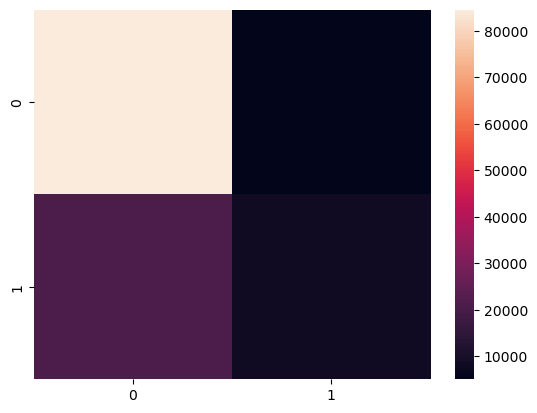

In [14]:
import seaborn as sns

sns.heatmap(confusion_matrix(y_train, knn.predict(X_train_std)))

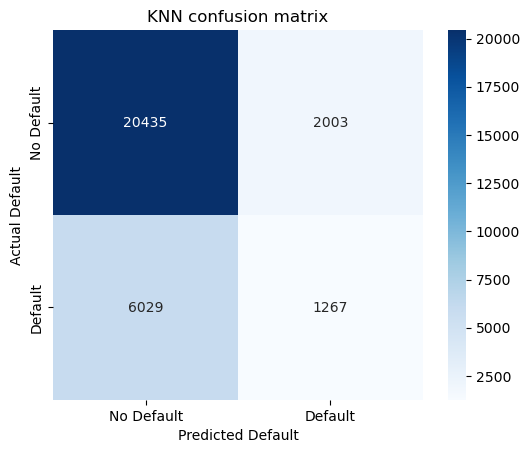

In [15]:
knn_confusion = confusion_matrix(y_test, knn.predict(X_test_std)) #X_train_std
                                 
sns.heatmap(
    knn_confusion, 
    cmap="Blues",  
    annot=True, 
    fmt="g",
    square=True,
    xticklabels=["No Default", "Default"],        
    yticklabels=["No Default", "Default"]
).set(
    xlabel='Predicted Default',
    ylabel='Actual Default',
    title='KNN confusion matrix'
);

In [16]:
from sklearn.model_selection import GridSearchCV

parameters = {"n_neighbors": range(1, 50)}

gridsearch = GridSearchCV(KNeighborsClassifier(), parameters)

gridsearch.fit(X_train_std, y_train)

gridsearch.best_params_

{'n_neighbors': 49}

Naudojamas **GridSearchCV**, kad būtų automatiškai parinkta **geriausia KNN parametro `n_neighbors` reikšmė**.

Veikimo principas:
- Sukuriamas parametrų rinkinys: `n_neighbors` nuo **1 iki 49**
- Modelis apmokomas su **skirtingomis parametro reikšmėmis**
- Kiekvienas variantas įvertinamas naudojant **cross-validation**

`gridsearch.best_params_` grąžina **parametro reikšmę, kuri duoda geriausią modelio rezultatą**.

**Manhattan distance** – atstumas tarp dviejų taškų apskaičiuojamas sudedant **absoliučius skirtumus tarp kiekvieno požymio**.  
Tai panašu į judėjimą miesto kvartalais: galima eiti tik horizontaliai ir vertikaliai.

Formulė:  
|x₁ − y₁| + |x₂ − y₂| + ... + |xₙ − yₙ|

**Minkowski distance** – bendresnė atstumo formulė, kuri apima kelis atstumo tipus.  
Keičiant parametrą **p**, galima gauti skirtingus atstumus:
- **p = 1** → Manhattan distance  
- **p = 2** → Euclidean distance

Todėl Minkowski yra **bendresnis metodas**, o Manhattan yra **vienas jo specialus atvejis**.

In [17]:
from sklearn.model_selection import GridSearchCV

parameters = {"n_neighbors": range(50, 100), "metric": ["minkowski", "manhattan"]}

gridsearch = GridSearchCV(KNeighborsClassifier(), parameters)

gridsearch.fit(X_train_std, y_train)

gridsearch.best_params_

{'metric': 'manhattan', 'n_neighbors': 54}

Naudojamas **GridSearchCV**, kad būtų parinkta geriausia **KNN modelio parametrų kombinacija**.

Tikrinami du parametrai:
- **n_neighbors** – kaimynų skaičius nuo **50 iki 99**
- **metric** – atstumo skaičiavimo būdas (**minkowski** arba **manhattan**)

GridSearchCV automatiškai išbando visas parametrų kombinacijas su **cross-validation** ir įvertina modelio veikimą.

`gridsearch.best_params_` grąžina **geriausią parametrų kombinaciją**, kuri duoda geriausią modelio rezultatą.

In [18]:
knn = KNeighborsClassifier(n_neighbors=49, metric="manhattan")

knn.fit(X_train_std, y_train)

knn.score(X_train_std, y_train)


0.7685225667585929

In [19]:
knn.score(X_test_std, y_test)

0.7672361606242013

Sukuriamas **K-Nearest Neighbors (KNN)** klasifikacijos modelis su:

- **n_neighbors = 49** – klasė nustatoma pagal **49 artimiausius kaimynus**
- **metric = "manhattan"** – atstumas tarp taškų skaičiuojamas naudojant **Manhattan distance**

Modelis apmokomas su **train duomenimis**, o tada įvertinamas naudojant **accuracy**.

Rezultatai:
- **Train accuracy:** 0.768  
- **Test accuracy:** 0.767  

Kadangi train ir test tikslumas yra labai panašūs, modelis **gerai generalizuoja** ir **nepastebima reikšmingo overfitting**.

In [20]:
knn.predict(X_test_std)

array([0, 1, 0, ..., 0, 0, 0], dtype=int64)

knn.predict(X_test_std) naudojama tam, kad modelis **prognozuotų klases testavimo duomenims**.

Rezultatas yra **masyvas su prognozuotomis klasėmis**, kur:
- **0** reiškia klientas **nebus default**
- **1** reiškia klientas **gali negrąžinti paskolos (default)**

Kiekviena reikšmė atitinka vieną stebėjimą test rinkinyje

In [21]:
knn.predict_proba(X_test_std)

array([[0.81632653, 0.18367347],
       [0.        , 1.        ],
       [0.85714286, 0.14285714],
       ...,
       [0.59183673, 0.40816327],
       [0.65306122, 0.34693878],
       [0.67346939, 0.32653061]])

knn.predict_proba(X_test_std) grąžina **prognozuojamas klasių tikimybes** kiekvienam stebėjimui.

Kiekviena eilutė turi dvi reikšmes:
- pirma reikšmė – **tikimybė, kad klasė = 0 (ne default)**
- antra reikšmė – **tikimybė, kad klasė = 1 (default)**
  


In [22]:
knn.predict_proba(np.array([ 0.46509119,  0.16254351, -0.03759113, -0.6213593 , -0.62969813,
         1.7133042 ]).reshape(1, -1))

array([[0.81632653, 0.18367347]])

[0.816, 0.184] reiškia, kad modelis vertina:
- 81.6 % tikimybę, kad klientas **nebus default**
- 18.4 % tikimybę, kad klientas **bus default**

Prognozuota klasė (`predict`) yra **ta, kurios tikimybė didžiausia**.
knn.predict_proba(...) naudojama apskaičiuoti **klasių tikimybes vienam naujam stebėjimui**.


Modelis pasirinktų **klasę 0**, nes jos tikimybė yra didesnė.

In [23]:
X_test_std

array([[ 0.46509119,  0.16254351, -0.03759113, -0.6213593 , -0.62969813,
         1.7133042 ],
       [-0.13314044, -1.15275524, -0.04052942, -0.6213593 ,  1.58806252,
        -0.58366751],
       [ 0.95455344,  1.74688064, -0.27348812, -0.6213593 ,  1.58806252,
        -0.58366751],
       ...,
       [-1.32960371, -0.68442917, -0.25683477, -0.6213593 ,  1.58806252,
        -0.58366751],
       [-0.78575677, -0.56485656, -0.03663839, -0.6213593 ,  1.58806252,
        -0.58366751],
       [-0.89452616, -0.78407302,  0.18662463, -0.6213593 ,  1.58806252,
        -0.58366751]])

`X_test_std` yra **standartizuotas testavimo duomenų rinkinys**, naudojamas modelio vertinimui.

Kiekviena eilutė atitinka **vieną stebėjimą (pvz., klientą)**, o kiekvienas stulpelis – **vieną požymį (feature)**.

Reikšmės yra **standartizuotos (Z-score)**, todėl:
- vidurkis ≈ **0**
- standartinis nuokrypis ≈ **1**

Tokie duomenys naudojami todėl, kad **KNN modelis remiasi atstumais**, o standartizavimas užtikrina, kad visi požymiai būtų **toje pačioje skalėje**.

In [24]:
bins = np.linspace(0, 1, 11)

bins

array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ])

C:\Users\User\AppData\Local\Temp\ipykernel_9468\1474549993.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("predicted_probability")


<Axes: xlabel='predicted_probability', ylabel='Event Rate'>

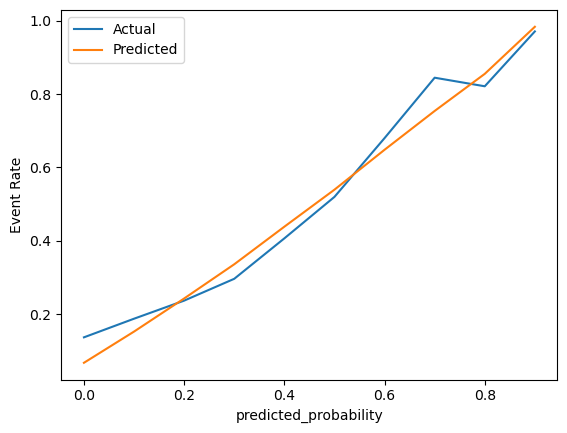

In [25]:
import numpy as np

bins = np.linspace(0, 1, 11)

# Create dataframe with Actual Classes & Predicted Probabilities
actual_vs_prob = (
    pd.DataFrame({
        "Actual": y_test,
        "Predicted": knn.predict_proba(X_test_std)[:, 1]}) #X_train_std
)

# Create bins at increments of .1
actual_vs_prob["predicted_probability"] = (
    pd.cut(actual_vs_prob["Predicted"], 
    bins=bins,
    labels = bins[:-1].round(2)
          )
)

# Group by probability bins and calculate actual even rate & plot
(actual_vs_prob
 .groupby("predicted_probability")
 .agg({"Actual": "mean", "Predicted": "mean"})
 .plot
 .line(ylabel="Event Rate")
)

**Kalibracijos (reliability) grafikas**, kuris parodo, ar modelio prognozuojamos tikimybės atitinka realų įvykio dažnį.


1) `knn.predict_proba(X_test_std)[:, 1]` paima **default (1 klasės) tikimybes** kiekvienam test stebėjimui.
2) `bins = np.linspace(0, 1, 11)` sukuria intervalus nuo 0 iki 1 kas 0.1 (0–0.1, 0.1–0.2, ...).
3) `pd.cut(..., bins=..., labels=...)` priskiria kiekvieną prognozuotą tikimybę vienam **binui** (pvz., 0.7).
4) `groupby(...).agg({"Actual":"mean","Predicted":"mean"})` kiekvienam binui paskaičiuoja:
   - `Actual mean` = **tikras įvykio dažnis** tame bine (kiek iš tikrųjų buvo default)
   - `Predicted mean` = **vidutinė prognozuota tikimybė** tame bine
5) `.plot.line()` nupiešia dvi linijas: **Actual** ir **Predicted**.

Kaip interpretuoti grafiką:
- Jei **Predicted** ir **Actual** linijos eina arti viena kitos, modelio tikimybės yra **gerai kalibruotos**.
- Jei **Predicted** yra aukščiau už **Actual**, modelis **pervertina riziką** (prognozuoja per dideles tikimybes).
- Jei **Predicted** yra žemiau už **Actual**, modelis **nuvertina riziką** (prognozuoja per mažas tikimybes).

In [26]:
actual_vs_prob.head()

,Actual,Predicted,predicted_probability
30254,1,0.183673,0.1
139346,1,1.000000,0.9
136057,0,0.142857,0.1
25804,1,0.102041,0.1
6971,0,0.408163,0.4


`actual_vs_prob` yra lentelė, kur kiekviena eilutė atitinka vieną test stebėjimą:
- **Actual** – tikra klasė (0 arba 1)
- **Predicted** – modelio prognozuota tikimybė klasei 1 (`predict_proba` stulpelis `[:, 1]`)
- **predicted_probability** – į kurį 0.1 intervalo „biną“ pateko prognozuota tikimybė (pvz., 0.183 → 0.1 binas)

In [27]:
(actual_vs_prob
 .groupby("predicted_probability", observed=True)
 .agg({"Actual": "mean", "Predicted": "mean"}))

,Actual,Predicted
predicted_probability,,
0.0,0.136296,0.066848
0.1,0.187138,0.152023
0.2,0.236467,0.242337
0.3,0.296046,0.335666
0.4,0.406367,0.438221
0.5,0.519573,0.539255
0.6,0.680000,0.648163
0.7,0.844828,0.754046
0.8,0.821429,0.855321


`groupby("predicted_probability").agg({"Actual":"mean","Predicted":"mean"})` suveda duomenis pagal binus ir apskaičiuoja:
- **Actual (mean)** – realus įvykio dažnis tame bine (pvz., bini 0.7 reiškia, kad ~0.845 stebėjimų iš tikrųjų buvo klasė 1)
- **Predicted (mean)** – vidutinė prognozuota tikimybė tame bine (pvz., bini 0.7 modelis vidutiniškai prognozavo ~0.754)

Interpretacija: jei **Actual mean** ir **Predicted mean** yra panašūs, tikimybės yra gerai kalibruotos; jei **Predicted < Actual**, modelis nuvertina riziką; jei **Predicted > Actual**, pervertina.v